# Table of Contents
1. [Importing the Libraries](#Importing-the-Libraries)
2. [Preparing the Dataset](#Preparing-the-Dataset)
3. [Encoding Categorical Variables](#Encoding-Categorical-Variables)
4. [Creating the Decision Tree Model](#Creating-the-Decision-Tree-Model)
   - a. [Splitting the Data into Features](#Splitting-the-Data-into-Features)
   - b. [Splitting the Dataset into Training and Testing Sets](#Splitting-the-Dataset-into-Training-and-Testing-Sets)
   - c. [Training the Decision Tree Classifier](#Training-the-Decision-Tree-Classifier)
   - d. [Predicting on the Test Set](#Predicting-on-the-Test-Set)
5. [Calculating Metrics](#Calculating-Metrics)
6. [Graphical Representations](#Graphical-Representations)
   - a. [Plotting the Decision Tree](#Plotting-the-Decision-Tree)
   - b. [Pie Chart for the Target Variable 'Play_Badminton'](#Pie-Chart-for-the-Target-Variable-Play_Badminton)
   - c. [Heatmap Matrix](#Heatmap-Matrix)
   - d. [Graphical-Relationship-Between-Humidity-and-Temperature-for-Play-or-Not'](#Graphical-Relationship-Between-Humidity-and-Temperature-for-Play-or-Not)

7.[Prediction](#Prediction)

# Importing the Libraries
<a id="Importing-the-Libraries"></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

# Preparing the Dataset
<a id="Preparing-the-Dataset"></a>
The code snippet reads a CSV file named `badminton_dataset.csv` into a pandas DataFrame called `df` using `pd.read_csv()`. The `df.head()` function then displays the first few rows (by default, 5) of the dataset to give an overview of the data structure and contents.

In [2]:
# Prepare the dataset
df = pd.read_csv("badminton_dataset.csv")

In [3]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play_Badminton
0,Overcast,Cool,High,Weak,Yes
1,Sunny,Mild,Normal,Strong,No
2,Rain,Mild,Normal,Strong,No
3,Sunny,Cool,High,Weak,Yes
4,Sunny,Cool,High,Strong,No


# Encoding Categorical Variables
<a id="Encoding-Categorical-Variables"></a>
This line of code uses `pd.get_dummies()` to perform one-hot encoding on the categorical columns `['Outlook', 'Temperature', 'Humidity', 'Wind']` in the DataFrame `df`. One-hot encoding transforms these categorical features into binary columns, making them suitable for machine learning algorithms that require numerical input. The result is stored in `df_encoded`.

In [4]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Outlook', 'Temperature', 'Humidity', 'Wind'])

# Creating the Decision Tree Model
<a id="Creating-the-Decision-Tree-Model"></a>
## Splitting the Data into Features
<a id="Splitting-the-Data-into-Features"></a>
This code separates the features and target variable from the encoded DataFrame. 

- **`X`**: Contains all the features by dropping the `Play_Badminton` column.
- **`y`**: Converts the `Play_Badminton` column into binary labels (1 for 'Yes', 0 for 'No'), making it suitable for classification tasks.

In [5]:
# Split the data into features (X) and target (y)
X = df_encoded.drop('Play_Badminton', axis=1)
y = df_encoded['Play_Badminton'].apply(lambda x: 1 if x == 'Yes' else 0)

## Splitting the Dataset into Training and Testing Sets
<a id="Splitting-the-Dataset-into-Training-and-Testing-Sets"></a>
This line splits the dataset into training and testing sets.

- **`X_train` and `y_train`**: Contain 70% of the data for training the model.
- **`X_test` and `y_test`**: Contain 30% of the data for testing the model.
- **`test_size=0.3`**: Specifies that 30% of the data should be used for testing.
- **`random_state=42`**: Ensures reproducibility by setting a seed for the random splitting process.

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Training the Decision Tree Classifier
<a id="Training-the-Decision-Tree-Classifier"></a>
This code initializes and trains a decision tree classifier.

- **`model = DecisionTreeClassifier(random_state=42)`**: Creates a decision tree model with a fixed random state for reproducibility.
- **`model.fit(X_train, y_train)`**: Trains the decision tree model using the training data (`X_train` and `y_train`).

In [7]:
# Train the decision tree classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Predicting on the Test Set
<a id="Predicting-on-the-Test-Set"></a>
This code generates predictions using the trained decision tree model.

- **`y_pred`**: Stores the predicted labels for the test set (`X_test`).
- **`model.predict(X_test)`**: Applies the model to the test data to predict the target values based on the learned patterns from the training data.

In [8]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculating Metrics
<a id="Calculating-Metrics"></a> 
This code evaluates the performance of the model by calculating various metrics:

- **`CM`**: Confusion matrix, showing the counts of true positives, true negatives, false positives, and false negatives.
- **`AS`**: Accuracy score, measuring the overall correctness of the model's predictions.
- **`RS`**: Recall score, indicating how well the model identifies positive cases.
- **`PS`**: Precision score, reflecting the accuracy of positive predictions.
- **`F1`**: F1 score, which is the harmonic mean of precision and recall.
- The metrics are then printed for analysis.

In [9]:
# Calculate metrics
CM = confusion_matrix(y_test, y_pred)
AS = accuracy_score(y_test, y_pred)
RS = recall_score(y_test, y_pred)
PS = precision_score(y_test, y_pred)
F1 = f1_score(y_test, y_pred)
# Display the metrics
print("Confusion Matrix:\n", CM)
print(f"Accuracy Score: {AS:.2f}")
print(f"Recall Score: {RS:.2f}")
print(f"Precision Score: {PS:.2f}")
print(f"F1 Score: {F1:.2f}")

Confusion Matrix:
 [[7 0]
 [0 4]]
Accuracy Score: 1.00
Recall Score: 1.00
Precision Score: 1.00
F1 Score: 1.00


# Graphical Representations
<a id="Graphical-Representations"></a>

## Plotting the Decision Tree
<a id="Plotting-the-Decision-Tree"></a>
This code visualizes the trained decision tree model.

- **`plt.figure(figsize=(20,10))`**: Creates a large figure for the plot (20x10 inches).
- **`plot_tree(...)`**: Visualizes the decision tree, with feature names, filled nodes, and rounded edges for clarity.
- **`plt.show()`**: Displays the plot, showing the structure and decisions of the tree.

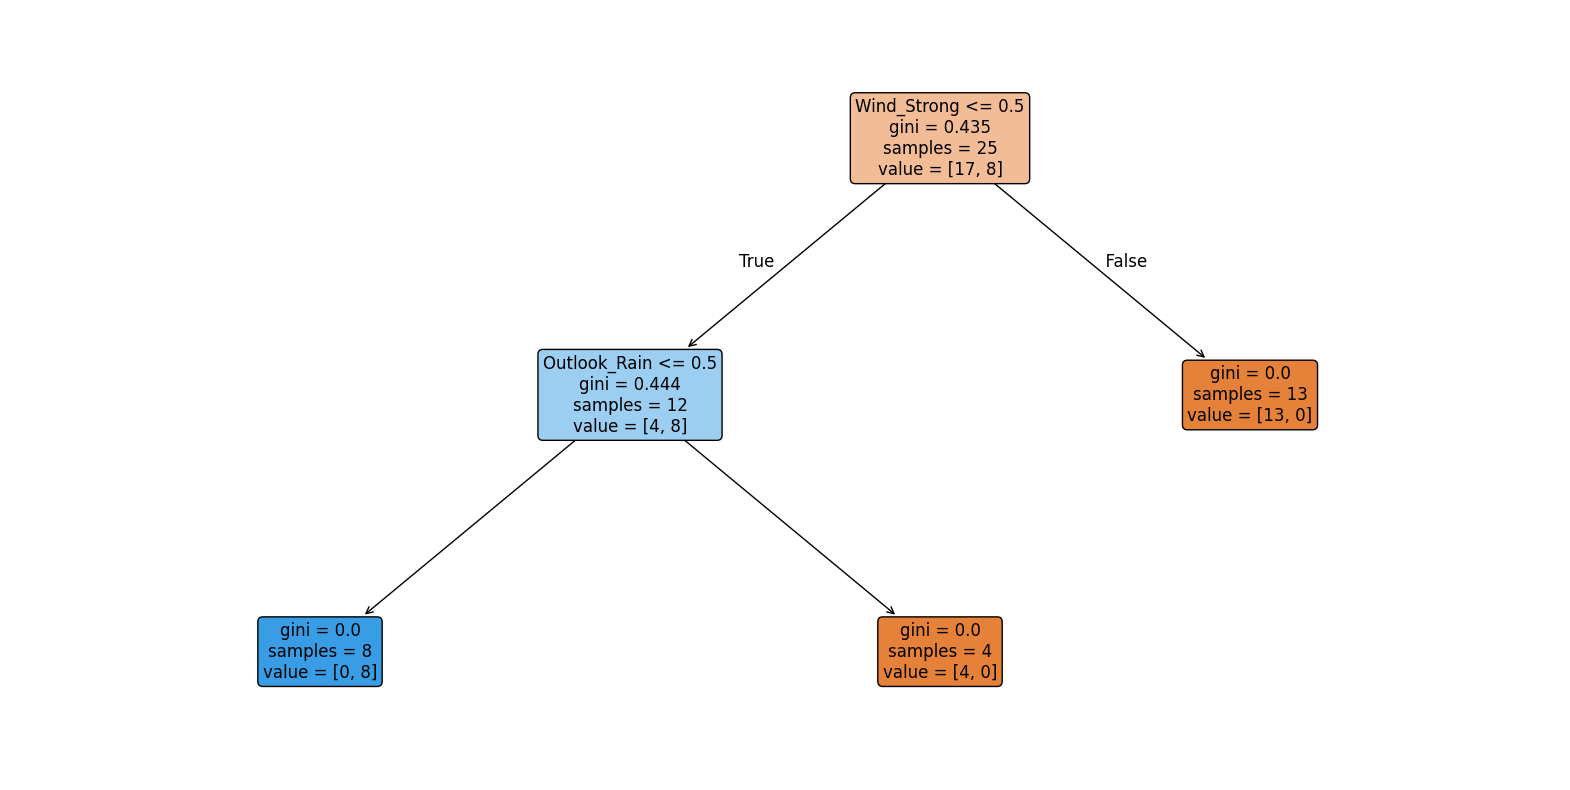

In [10]:
# --- Plot the Decision Tree ---
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, fontsize=12)
plt.show()

## Pie Chart for the Target Variable 'Play_Badminton'
<a id="Pie-Chart-for-the-Target-Variable-Play_Badminton"></a>
This code creates a pie chart to visualize the distribution of the `Play_Badminton` column:

- **`play_counts`**: Counts occurrences of each class ('Yes' or 'No') in the `Play_Badminton` column.
- **`plt.pie(...)`**: Generates a pie chart with percentage labels and specified colors.
- **`plt.title('Distribution of Play_Badminton')`**: Adds a title to the pie chart.
- **`plt.show()`**: Displays the pie chart, illustrating the proportion of each class in the dataset.

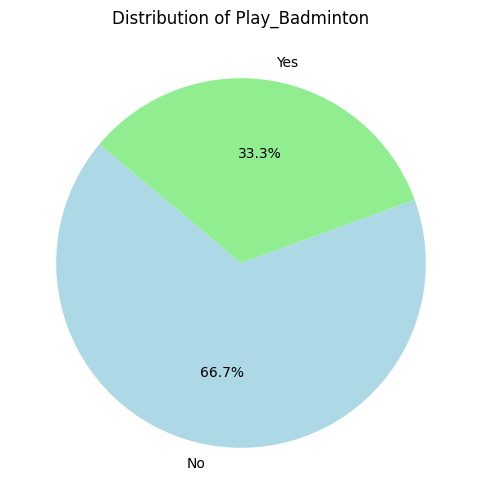

In [11]:
# Pie chart for the target variable 'Play_Badminton'
play_counts = df['Play_Badminton'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'lightgreen'])
plt.title('Distribution of Play_Badminton')
plt.show()

## Heatmap Matrix
<a id="Heatmap-Matrix"></a>
This code generates a heatmap of the confusion matrix:

- **`sns.heatmap(CM, annot=True, fmt='d', cmap='Reds', ...)`**: Creates a heatmap with annotated values and a red color map to visualize the confusion matrix.
- **`xticklabels` and `yticklabels`**: Label the axes to indicate whether predictions and actual values are 'Not Play' or 'Play'.
- **`plt.title('Confusion Matrix Heatmap')`**: Adds a title to the heatmap.
- **`plt.show()`**: Displays the heatmap, highlighting the performance of the classification model.

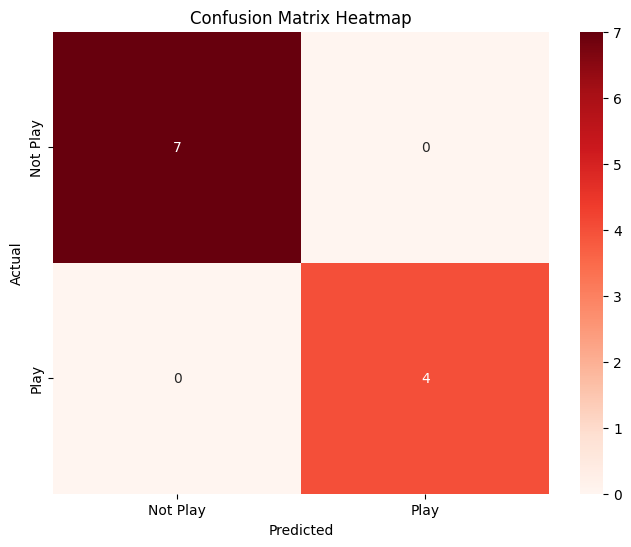

In [12]:
# Heatmap Matrix
plt.figure(figsize=(8,6))
sns.heatmap(CM, annot=True, fmt='d', cmap='Reds', xticklabels=['Not Play', 'Play'], yticklabels=['Not Play', 'Play'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Graphical Relationship Between Humidity and Temperature for 'Play or Not'
<a id="Graphical-Relationship-Between-Humidity-and-Temperature-for-Play-or-Not"></a>
This code creates a scatter plot to visualize the relationship between `Temperature` and `Humidity`:

- **`sns.scatterplot(x='Temperature', y='Humidity', hue='Play_Badminton', data=df)`**: Plots `Temperature` on the x-axis and `Humidity` on the y-axis, with points colored based on whether `Play_Badminton` is 'Yes' or 'No'.
- **`plt.title('Scatter Plot of Temperature vs. Humidity')`**: Adds a title to the scatter plot.
- **`plt.xlabel('Temperature')`** and **`plt.ylabel('Humidity')`**: Label the x and y axes.
- **`plt.show()`**: Displays the scatter plot, revealing patterns or clusters in the data.

<Figure size 1500x500 with 0 Axes>

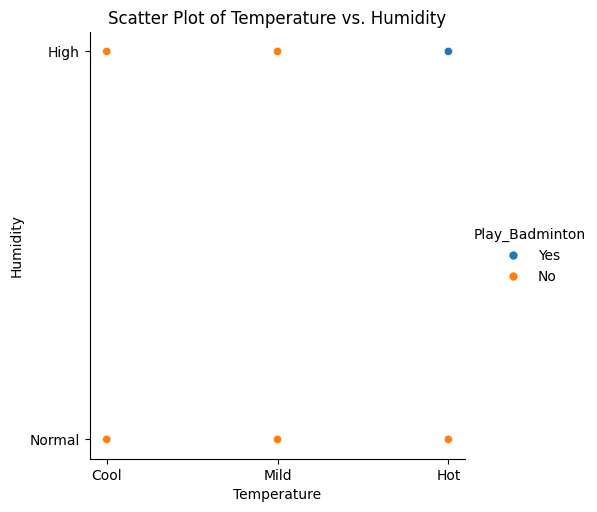

In [13]:
plt.figure(figsize=(15,5))
sns.relplot(x='Temperature', y='Humidity', hue='Play_Badminton', data=df)
plt.title('Scatter Plot of Temperature vs. Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.show()

<Figure size 1500x500 with 0 Axes>

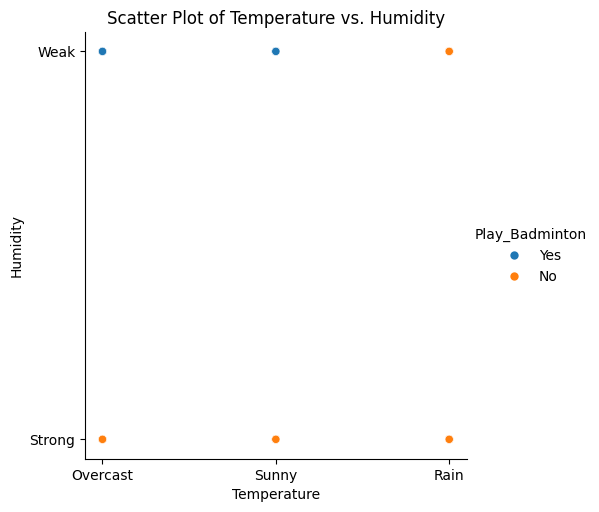

In [14]:
plt.figure(figsize=(15,5))
sns.relplot(x='Outlook', y='Wind', hue='Play_Badminton', data=df)
plt.title('Scatter Plot of Temperature vs. Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.show()

## Taking user input '
<a id="Prediction"></a>
In this we are taking user input and predicting the if user can play or not 

In [15]:
# --- User Input Section ---
# Gather user input for prediction
while True:
    try:
        user_outlook = input("Enter the Outlook (Sunny, Overcast, Rain): ").capitalize()
        if not user_outlook.isalpha() or user_outlook not in ["Sunny", "Overcast", "Rain"]:
            raise ValueError("Invalid input for Outlook")

        user_temperature = input("Enter the Temperature (Hot, Mild, Cool): ").capitalize()
        if not user_temperature.isalpha() or user_temperature not in ["Hot", "Mild", "Cool"]:
            raise ValueError("Invalid input for Temperature")

        user_humidity = input("Enter the Humidity (High, Normal): ").capitalize()
        if not user_humidity.isalpha() or user_humidity not in ["High", "Normal"]:
            raise ValueError("Invalid input for Humidity")

        user_wind = input("Enter the Wind (Weak, Strong): ").capitalize()
        if not user_wind.isalpha() or user_wind not in ["Weak", "Strong"]:
            raise ValueError("Invalid input for Wind")

        # If all inputs are valid, break out of the loop
        break

    except ValueError:
        print('wrong input')

# Create a DataFrame for the user input
user_input = pd.DataFrame({'Outlook': [user_outlook],'Temperature': [user_temperature],'Humidity': [user_humidity],'Wind': [user_wind]})

# One-hot encode the user input
user_input_encoded = pd.get_dummies(user_input)
user_input_encoded = user_input_encoded.reindex(columns=X_train.columns, fill_value=0)

# Predict whether badminton will be played
user_prediction = model.predict(user_input_encoded)

# Display the prediction
if user_prediction[0] == 1:
    print("Prediction: Badminton will be played!")
else:
    print("Prediction: Badminton will NOT be played.")


Enter the Outlook (Sunny, Overcast, Rain):  sunny
Enter the Temperature (Hot, Mild, Cool):  mild
Enter the Humidity (High, Normal):  high
Enter the Wind (Weak, Strong):  strong


Prediction: Badminton will NOT be played.
